# Reuters Fact Check: spider-level EDA

Fixed sections:
1. Run selection and player evidence
2. Volume, temporal coverage, and quality overview
3. Text-length histograms by original_label and standard_label
4. Category, topic/tag, and temporal distribution
5. Missing fields and invalid dates
6. Cleaning and normalization review
7. NLP with stop-word removal, lemmas, and NER
8. Processed JSONL export


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display


def _find_repo_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().resolve().parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("Repositorio nao encontrado a partir do diretorio atual.")


REPO_ROOT = _find_repo_root()
for path in (REPO_ROOT, REPO_ROOT / "src", REPO_ROOT / "notebooks"):
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

import eda_utils as eu

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 160)
sns.set_theme(style="whitegrid", palette="crest")

## Run selection and player evidence

In [2]:
SPIDER = "reuters_fact_check"
PLAYER = "Reuters Fact Check"
DATA_DIR = eu.resolve_data_dir(str(REPO_ROOT / "data"))
SNAPSHOT_ID = None
BATCH_SIZE = 64

selection = eu.select_spider_run(DATA_DIR, SPIDER)
profile = eu.get_spider_profile(SPIDER)
display(eu.selection_to_frame(selection))
profile

,spider,agency_id,agency_name,selected_run_id,latest_run_id,latest_valid_run_id,fallback_applied,selection_reason,cleaning_flags,diagnostic_run_ids
0,reuters_fact_check,reuters,Reuters Fact Check,20260315T185726Z-1d124ed3,20260315T185726Z-1d124ed3,20260315T185726Z-1d124ed3,False,latest_valid_run,"html_unescape, unicode_normalize, collapse_whitespace, light_encoding_fix",


SpiderProfile(spider='reuters_fact_check', display_name='Reuters Fact Check', analysis_field_order=('title', 'claim', 'summary'), ignored_analysis_titles=frozenset(), dropped_export_titles=frozenset(), extract_label_prefix_before_colon=False, diagnostic_run_ids=(), cleaning_flags=('html_unescape', 'unicode_normalize', 'collapse_whitespace', 'light_encoding_fix'))

In [3]:
runs_df = eu.load_runs_df(DATA_DIR)
spider_runs = runs_df.loc[runs_df["spider"] == SPIDER].sort_values(
    "run_started_at", ascending=False
)
evidence_cols = [
    "run_id",
    "run_started_at",
    "run_finished_at",
    "items_seen",
    "items_stored",
    "items_deduped",
    "items_invalid",
    "has_items_file",
    "is_valid",
]
display(spider_runs[evidence_cols].head(10))

diagnostic_df = eu.diagnostic_runs_df(DATA_DIR, SPIDER)
if not diagnostic_df.empty:
    print("Diagnostic runs configured for this spider:")
    display(diagnostic_df[evidence_cols])

,run_id,run_started_at,run_finished_at,items_seen,items_stored,items_deduped,items_invalid,has_items_file,is_valid
34,20260315T185726Z-1d124ed3,2026-03-15 18:57:26+00:00,2026-03-15 20:57:17+00:00,1500,1500,0,0,True,True
33,20260315T183439Z-d0754764,2026-03-15 18:34:39+00:00,2026-03-15 18:44:49+00:00,0,0,0,0,False,False
32,20260315T182620Z-3649284f,2026-03-15 18:26:21+00:00,2026-03-15 18:27:24+00:00,0,0,0,0,False,False
23,20260315T010005Z-1d265f16,2026-03-15 01:00:05+00:00,2026-03-15 07:03:08+00:00,94,94,0,0,True,True
0,20260304T053909Z-4c2dcf13,2026-03-04 05:39:10+00:00,2026-03-04 05:39:11+00:00,0,0,0,0,False,False


## Volume, temporal coverage, and quality overview

In [4]:
nlp = eu.load_nlp_model()
raw_df = eu.load_spider_items_df(DATA_DIR, SPIDER, selection.selected_run_id)
selection, processed_records = eu.build_processed_records(
    DATA_DIR,
    SPIDER,
    selection=selection,
    nlp=nlp,
    batch_size=BATCH_SIZE,
)
processed_df = eu.processed_records_to_df(processed_records)
processed_df["published_at_dt"] = pd.to_datetime(
    processed_df["published_at"], utc=True, errors="coerce"
)

overview = pd.DataFrame(
    [
        {
            "player": PLAYER,
            "selected_run_id": selection.selected_run_id,
            "latest_run_id": selection.latest_run_id,
            "fallback_applied": selection.fallback_applied,
            "raw_rows": len(raw_df),
            "processed_rows": len(processed_df),
            "dropped_rows": len(raw_df) - len(processed_df),
            "coverage_start": processed_df["published_at_dt"].min(),
            "coverage_end": processed_df["published_at_dt"].max(),
            "invalid_dates": int(processed_df["published_at_dt"].isna().sum()),
            "missing_original_label": int(processed_df["original_label"].isna().sum()),
        }
    ]
)
display(overview)
display(raw_df.head(3))
display(processed_df.head(3))

,player,selected_run_id,latest_run_id,fallback_applied,raw_rows,processed_rows,dropped_rows,coverage_start,coverage_end,invalid_dates,missing_original_label
0,Reuters Fact Check,20260315T185726Z-1d124ed3,20260315T185726Z-1d124ed3,False,1500,1500,0,2023-10-10 14:47:20.788000+00:00,2026-03-13 20:43:23.770000+00:00,1,1204


,item_id,agency_id,agency_name,spider,source_url,canonical_url,title,published_at,collected_at,claim,summary,verdict,rating,language,country,topics,tags,entities,source_type,run_id,published_at_dt,collected_at_dt,lag_hours,title_len,claim_len,summary_len,canonical_host,source_equals_canonical
0,ad8b70352b680f101642208885162172161bf898556680b0be58e46a13e3a015,reuters,Reuters Fact Check,reuters_fact_check,https://www.reuters.com/fact-check/portugues/XTSGRBYWAJKUFM54CTKPMYSQSE-2026-03-04/,https://www.reuters.com/fact-check/portugues/XTSGRBYWAJKUFM54CTKPMYSQSE-2026-03-04,"Checagem de fatos: Vídeo mostra incêndio em prédio residencial, não ataque a sede da CIA em Dubai",2026-03-04T17:23:52.584Z,2026-03-15T18:57:38+00:00,"Checagem de fatos: Vídeo mostra incêndio em prédio residencial, não ataque a sede da CIA em Dubai",Um vídeo de uma coluna de fumaça saindo de um prédio não mostra um ataque do Irã à sede da Agência ​Central de Inteligência dos Estados Unidos (CIA) em Duba...,NaN,NaN,pt,None,[Checagem de fatos],"[PT-AMERS, PT-BR, PT-EMRG, PT-LATAM, PT-SAMER]",[],NewsArticle,20260315T185726Z-1d124ed3,2026-03-04 17:23:52.584000+00:00,2026-03-15 18:57:38+00:00,265.562616,97,97,252,www.reuters.com,0.0
1,d44262b5a5f2fc1be71b5181a9e3ff795928447b9d98b0be3e67e5b1857c9777,reuters,Reuters Fact Check,reuters_fact_check,https://www.reuters.com/fact-check/portugues/HHBPBFH5F5OJPPQ5HKVKLGYN2U-2026-03-04/,https://www.reuters.com/fact-check/portugues/HHBPBFH5F5OJPPQ5HKVKLGYN2U-2026-03-04,"Checagem de fatos: Vídeo de incêndio mostra porto no Iêmen, não refinaria saudita alvo do Irã",2026-03-04T17:36:04.962Z,2026-03-15T18:57:41+00:00,"Checagem de fatos: Vídeo de incêndio mostra porto no Iêmen, não refinaria saudita alvo do Irã","Imagens de um incêndio que circulam nas redes sociais mostram o porto de Hodeida, ​no Iêmen, após um ataque israelense em 2024. ‌Publicações com o registro,...",NaN,NaN,pt,None,[Checagem de fatos],[],[],NewsArticle,20260315T185726Z-1d124ed3,2026-03-04 17:36:04.962000+00:00,2026-03-15 18:57:41+00:00,265.360011,93,93,269,www.reuters.com,0.0
2,d05f6af5e5cd3ba1bf4ce7bb6c1b993972a6618ac489cbbf0f6a74fa592ff692,reuters,Reuters Fact Check,reuters_fact_check,https://www.reuters.com/fact-check/portugues/ZWYTBS3BZ5IX7ASKJYORMXGS7I-2026-03-04/,https://www.reuters.com/fact-check/portugues/ZWYTBS3BZ5IX7ASKJYORMXGS7I-2026-03-04,"Checagem de fatos: Vídeo mostra incidente com avião nos EUA, não ataque do Irã a aeroporto de Israel",2026-03-04T18:31:11.971Z,2026-03-15T18:57:44+00:00,"Checagem de fatos: Vídeo mostra incidente com avião nos EUA, não ataque do Irã a aeroporto de Israel","Imagens de pessoas saindo de um avião em um escorregador em meio a fumaça não têm relação com ​os recentes ataques entre Irã e Israel, como afirmam postagen...",NaN,NaN,pt,None,[Checagem de fatos],[],[],NewsArticle,20260315T185726Z-1d124ed3,2026-03-04 18:31:11.971000+00:00,2026-03-15 18:57:44+00:00,264.442230,100,100,257,www.reuters.com,0.0


,record_id,source_record_id,dataset_id,source_url,published_at,language,title,author,subtitle,claim_text,body_text,analysis_text,text_for_ner,text_without_stopwords,lemmatized_text,original_label,standard_label,category,entities,variant,metadata.analysis_text_length,metadata.entity_count,metadata.spider,metadata.agency_id,metadata.agency_name,metadata.run_id,metadata.latest_run_id,metadata.fallback_applied,metadata.source_type,metadata.source_topics,metadata.source_tags,metadata.source_rating,published_at_dt
0,factcheck_scrape_reuters_fact_check:ad8b70352b680f101642208885162172161bf898556680b0be58e46a13e3a015,ad8b70352b680f101642208885162172161bf898556680b0be58e46a13e3a015,factcheck_scrape_reuters_fact_check,https://www.reuters.com/fact-check/portugues/XTSGRBYWAJKUFM54CTKPMYSQSE-2026-03-04/,2026-03-04T17:23:52.584000+00:00,pt,"Checagem de fatos: Vídeo mostra incêndio em prédio residencial, não ataque a sede da CIA em Dubai",None,None,"Checagem de fatos: Vídeo mostra incêndio em prédio residencial, não ataque a sede da CIA em Dubai",Um vídeo de uma coluna de fumaça saindo de um prédio não mostra um ataque do Irã à sede da Agência ​Central de Inteligência dos Estados Unidos (CIA) em Duba...,"checagem de fatos: vídeo mostra incêndio em prédio residencial, não ataque a sede da cia em dubai um vídeo de uma coluna de fumaça saindo de um prédio não m...","checagem de fatos: vídeo mostra incêndio em prédio residencial, não ataque a sede da cia em dubai um vídeo de uma coluna de fumaça saindo de um prédio não m...",checagem fatos vídeo mostra incêndio prédio residencial ataque sede cia dubai vídeo coluna fumaça saindo prédio mostra ataque irã sede agência ​central inte...,checagem de fato vídeo mostrar incêndio em prédio residencial não ataque o sede de o cia em dubai um vídeo de um coluna de fumaça sair de um prédio não most...,NaN,missing,Checagem de fatos,"[{'text': 'cia', 'label': 'ORG', 'start_char': 85, 'end_char': 88}, {'text': 'dubai', 'label': 'LOC', 'start_char': 92, 'end_char': 97}, {'text': 'irã', 'la...",claim_summary,350,7,reuters_fact_check,reuters,Reuters Fact Check,20260315T185726Z-1d124ed3,20260315T185726Z-1d124ed3,False,NewsArticle,[Checagem de fatos],"[PT-AMERS, PT-BR, PT-EMRG, PT-LATAM, PT-SAMER]",NaN,2026-03-04 17:23:52.584000+00:00
1,factcheck_scrape_reuters_fact_check:d44262b5a5f2fc1be71b5181a9e3ff795928447b9d98b0be3e67e5b1857c9777,d44262b5a5f2fc1be71b5181a9e3ff795928447b9d98b0be3e67e5b1857c9777,factcheck_scrape_reuters_fact_check,https://www.reuters.com/fact-check/portugues/HHBPBFH5F5OJPPQ5HKVKLGYN2U-2026-03-04/,2026-03-04T17:36:04.962000+00:00,pt,"Checagem de fatos: Vídeo de incêndio mostra porto no Iêmen, não refinaria saudita alvo do Irã",None,None,"Checagem de fatos: Vídeo de incêndio mostra porto no Iêmen, não refinaria saudita alvo do Irã","Imagens de um incêndio que circulam nas redes sociais mostram o porto de Hodeida, ​no Iêmen, após um ataque israelense em 2024. ‌Publicações com o registro,...","checagem de fatos: vídeo de incêndio mostra porto no iêmen, não refinaria saudita alvo do irã imagens de um incêndio que circulam nas redes sociais mostram ...","checagem de fatos: vídeo de incêndio mostra porto no iêmen, não refinaria saudita alvo do irã imagens de um incêndio que circulam nas redes sociais mostram ...",checagem fatos vídeo incêndio mostra porto iêmen refinaria saudita alvo irã imagens incêndio circulam redes sociais mostram porto hodeida ​no iêmen ataque i...,checagem de fato vídeo de incêndio mostrar porto em o iêmen não refinar saudita alvo de o irã imagem de um incêndio que circular em o rede social mostrar o ...,NaN,missing,Checagem de fatos,"[{'text': 'iêmen', 'label': 'LOC', 'start_char': 53, 'end_char': 58}, {'text': 'irã', 'label': 'ORG', 'start_char': 90, 'end_char': 93}, {'text': 'hodeida',...",claim_summary,363,5,reuters_fact_check,reuters,Reuters Fact Check,20260315T185726Z-1d124ed3,20260315T185726Z-1d124ed3,False,NewsArticle,[Checagem de fatos],[],NaN,2026-03-04 17:36:04.962000+

## Text-length histograms by label

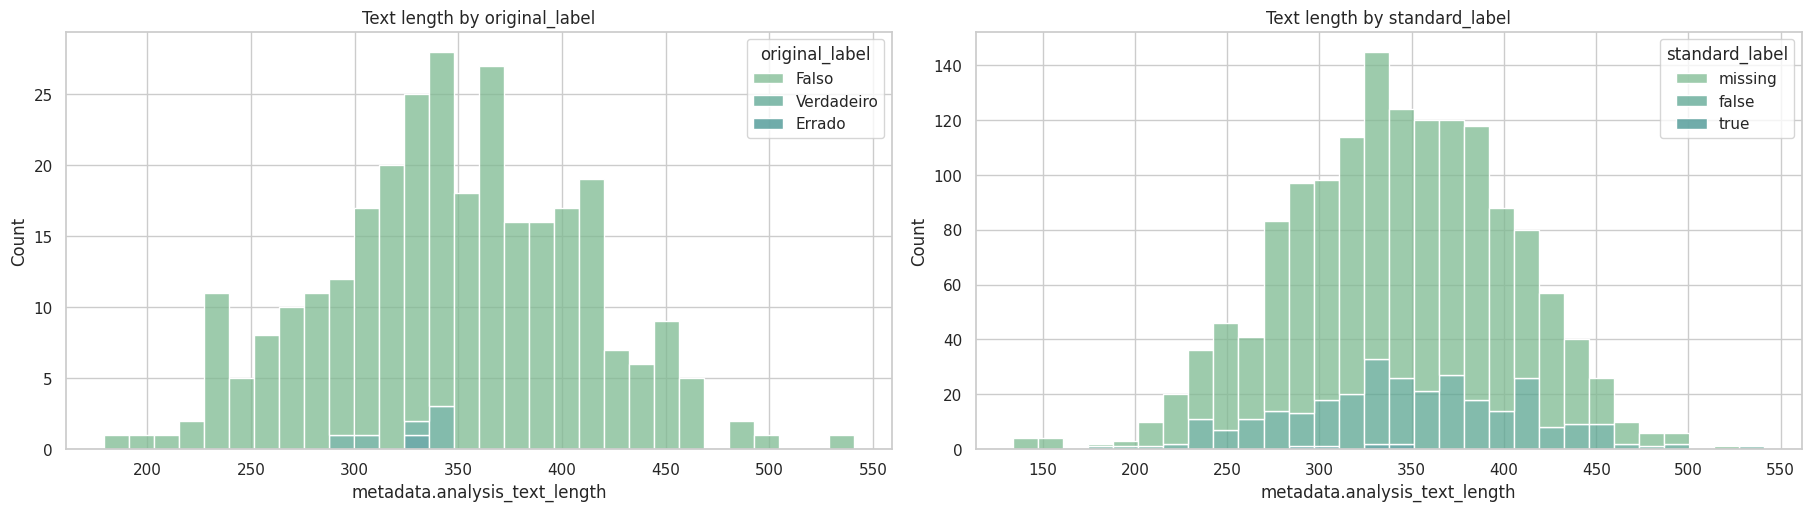

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5), constrained_layout=True)
sns.histplot(
    data=processed_df,
    x="metadata.analysis_text_length",
    hue="original_label",
    bins=30,
    multiple="stack",
    ax=axes[0],
)
axes[0].set_title("Text length by original_label")

sns.histplot(
    data=processed_df,
    x="metadata.analysis_text_length",
    hue="standard_label",
    bins=30,
    multiple="stack",
    ax=axes[1],
)
axes[1].set_title("Text length by standard_label")
plt.show()

## Category, topic/tag, temporal distribution, and data quality

In [6]:
topic_counts = raw_df["topics"].explode().dropna().value_counts().head(20)
tag_counts = raw_df["tags"].explode().dropna().value_counts().head(20)
category_counts = processed_df["category"].value_counts(dropna=False).head(20)

display(category_counts.rename_axis("category").reset_index(name="count"))
display(topic_counts.rename_axis("topic").reset_index(name="count"))
display(tag_counts.rename_axis("tag").reset_index(name="count"))

monthly = (
    processed_df.dropna(subset=["published_at_dt"])
    .assign(month=lambda df: df["published_at_dt"].dt.to_period("M").dt.to_timestamp())
    .groupby("month")
    .size()
    .reset_index(name="count")
)
display(monthly.tail(24))

missing_fields = (
    raw_df[["title", "claim", "summary", "verdict", "rating", "published_at"]]
    .isna()
    .sum()
    .rename_axis("field")
    .reset_index(name="missing_count")
)
display(missing_fields)

display(
    processed_df.loc[
        processed_df["published_at_dt"].isna(), ["source_record_id", "title", "published_at"]
    ].head(20)
)

,category,count
0,Checagem de fatos,1500


,topic,count
0,Checagem de fatos,1500


,tag,count
0,PT-AMERS,211
1,PT-EMRG,190
2,PT-LATAM,180
3,PT-SAMER,180
4,PT-BR,170
5,PT-GEN,40
6,PT-NAMER,31
7,PT-US,30
8,PT-POL,29
9,PT-POTUS,28


/tmp/ipykernel_2042854/1119197242.py:11: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .assign(month=lambda df: df["published_at_dt"].dt.to_period("M").dt.to_timestamp())


,month,count
6,2024-04-01,50
7,2024-05-01,55
8,2024-06-01,54
9,2024-07-01,54
10,2024-08-01,55
11,2024-09-01,58
12,2024-10-01,70
13,2024-11-01,50
14,2024-12-01,51
15,2025-01-01,56


,field,missing_count
0,title,0
1,claim,0
2,summary,0
3,verdict,1204
4,rating,1204
5,published_at,0


,source_record_id,title,published_at
1004,dc237d11eee193a2361e6b7a5d9dfeef506fc06a908887a0906dce14bb605472,Checagem de fatos: Notícia sobre estatal ucraniana é de 2023; Antonov negou ter representantes no Brasil,2024-03-06T20:41:37+00:00


## Cleaning and normalization review

In [7]:
comparison = raw_df.rename(
    columns={
        "item_id": "source_record_id",
        "title": "raw_title",
        "claim": "raw_claim",
        "summary": "raw_summary",
        "published_at": "raw_published_at",
        "verdict": "raw_verdict",
    }
).merge(
    processed_df[
        [
            "source_record_id",
            "title",
            "claim_text",
            "body_text",
            "analysis_text",
            "original_label",
            "standard_label",
            "published_at",
        ]
    ],
    on="source_record_id",
    how="left",
)
display(comparison.head(15))

,source_record_id,agency_id,agency_name,spider,source_url,canonical_url,raw_title,raw_published_at,collected_at,raw_claim,raw_summary,raw_verdict,rating,language,country,topics,tags,entities,source_type,run_id,published_at_dt,collected_at_dt,lag_hours,title_len,claim_len,summary_len,canonical_host,source_equals_canonical,title,claim_text,body_text,analysis_text,original_label,standard_label,published_at
0,ad8b70352b680f101642208885162172161bf898556680b0be58e46a13e3a015,reuters,Reuters Fact Check,reuters_fact_check,https://www.reuters.com/fact-check/portugues/XTSGRBYWAJKUFM54CTKPMYSQSE-2026-03-04/,https://www.reuters.com/fact-check/portugues/XTSGRBYWAJKUFM54CTKPMYSQSE-2026-03-04,"Checagem de fatos: Vídeo mostra incêndio em prédio residencial, não ataque a sede da CIA em Dubai",2026-03-04T17:23:52.584Z,2026-03-15T18:57:38+00:00,"Checagem de fatos: Vídeo mostra incêndio em prédio residencial, não ataque a sede da CIA em Dubai",Um vídeo de uma coluna de fumaça saindo de um prédio não mostra um ataque do Irã à sede da Agência ​Central de Inteligência dos Estados Unidos (CIA) em Duba...,NaN,NaN,pt,None,[Checagem de fatos],"[PT-AMERS, PT-BR, PT-EMRG, PT-LATAM, PT-SAMER]",[],NewsArticle,20260315T185726Z-1d124ed3,2026-03-04 17:23:52.584000+00:00,2026-03-15 18:57:38+00:00,265.562616,97,97,252,www.reuters.com,0.0,"Checagem de fatos: Vídeo mostra incêndio em prédio residencial, não ataque a sede da CIA em Dubai","Checagem de fatos: Vídeo mostra incêndio em prédio residencial, não ataque a sede da CIA em Dubai",Um vídeo de uma coluna de fumaça saindo de um prédio não mostra um ataque do Irã à sede da Agência ​Central de Inteligência dos Estados Unidos (CIA) em Duba...,"checagem de fatos: vídeo mostra incêndio em prédio residencial, não ataque a sede da cia em dubai um vídeo de uma coluna de fumaça saindo de um prédio não m...",NaN,missing,2026-03-04T17:23:52.584000+00:00
1,d44262b5a5f2fc1be71b5181a9e3ff795928447b9d98b0be3e67e5b1857c9777,reuters,Reuters Fact Check,reuters_fact_check,https://www.reuters.com/fact-check/portugues/HHBPBFH5F5OJPPQ5HKVKLGYN2U-2026-03-04/,https://www.reuters.com/fact-check/portugues/HHBPBFH5F5OJPPQ5HKVKLGYN2U-2026-03-04,"Checagem de fatos: Vídeo de incêndio mostra porto no Iêmen, não refinaria saudita alvo do Irã",2026-03-04T17:36:04.962Z,2026-03-15T18:57:41+00:00,"Checagem de fatos: Vídeo de incêndio mostra porto no Iêmen, não refinaria saudita alvo do Irã","Imagens de um incêndio que circulam nas redes sociais mostram o porto de Hodeida, ​no Iêmen, após um ataque israelense em 2024. ‌Publicações com o registro,...",NaN,NaN,pt,None,[Checagem de fatos],[],[],NewsArticle,20260315T185726Z-1d124ed3,2026-03-04 17:36:04.962000+00:00,2026-03-15 18:57:41+00:00,265.360011,93,93,269,www.reuters.com,0.0,"Checagem de fatos: Vídeo de incêndio mostra porto no Iêmen, não refinaria saudita alvo do Irã","Checagem de fatos: Vídeo de incêndio mostra porto no Iêmen, não refinaria saudita alvo do Irã","Imagens de um incêndio que circulam nas redes sociais mostram o porto de Hodeida, ​no Iêmen, após um ataque israelense em 2024. ‌Publicações com o registro,...","checagem de fatos: vídeo de incêndio mostra porto no iêmen, não refinaria saudita alvo do irã imagens de um incêndio que circulam nas redes sociais mostram ...",NaN,missing,2026-03-04T17:36:04.962000+00:00
2,d05f6af5e5cd3ba1bf4ce7bb6c1b993972a6618ac489cbbf0f6a74fa592ff692,reuters,Reuters Fact Check,reuters_fact_check,https://www.reuters.com/fact-check/portugues/ZWYTBS3BZ5IX7ASKJYORMXGS7I-2026-03-04/,https://www.reuters.com/fact-check/portugues/ZWYTBS3BZ5IX7ASKJYORMXGS7I-2026-03-04,"Checagem de fatos: Vídeo mostra incidente com avião nos EUA, não ataque do Irã a aeroporto de Israel",2026-03-04T18:31:11.971Z,2026-03-15T18:57:44+00:00,"Checagem de fatos: Vídeo mostra incidente com avião nos EUA, não ataque do Irã a aeroporto de Israel","Imagens de pessoas saindo de um avião em um escorregador em meio a fumaça não têm relação com ​os recentes ataques entre Irã e Israel, como afirm

## NLP outputs

In [8]:
lemma_counts = (
    processed_df["lemmatized_text"].str.split().explode().dropna().value_counts().head(20)
)
display(lemma_counts.rename_axis("lemma").reset_index(name="count"))

entity_series = processed_df["entities"].explode().dropna()
if entity_series.empty:
    entity_df = pd.DataFrame(columns=["text", "label", "start_char", "end_char"])
else:
    entity_df = pd.json_normalize(entity_series)

display(entity_df.head(20))
display(entity_df["label"].value_counts().rename_axis("label").reset_index(name="count"))
display(processed_df[["source_record_id", "text_without_stopwords", "lemmatized_text"]].head(10))

,lemma,count
0,o,11652
1,de,10048
2,em,4844
3,um,2728
4,que,2136
5,não,1858
6,ser,1803
7,fato,1507
8,checagem,1469
9,a,1404


,text,label,start_char,end_char
0,cia,ORG,85,88
0,dubai,LOC,92,97
0,irã,LOC,175,178
0,agência ​central,LOC,189,205
0,estados unidos,LOC,226,240
0,dubai,LOC,250,255
0,emirados árabes unidos,LOC,319,341
1,iêmen,LOC,53,58
1,irã,ORG,90,93
1,hodeida,LOC,167,174


,label,count
0,LOC,2700
1,PER,2136
2,ORG,643
3,MISC,377


,source_record_id,text_without_stopwords,lemmatized_text
0,ad8b70352b680f101642208885162172161bf898556680b0be58e46a13e3a015,checagem fatos vídeo mostra incêndio prédio residencial ataque sede cia dubai vídeo coluna fumaça saindo prédio mostra ataque irã sede agência ​central inte...,checagem de fato vídeo mostrar incêndio em prédio residencial não ataque o sede de o cia em dubai um vídeo de um coluna de fumaça sair de um prédio não most...
1,d44262b5a5f2fc1be71b5181a9e3ff795928447b9d98b0be3e67e5b1857c9777,checagem fatos vídeo incêndio mostra porto iêmen refinaria saudita alvo irã imagens incêndio circulam redes sociais mostram porto hodeida ​no iêmen ataque i...,checagem de fato vídeo de incêndio mostrar porto em o iêmen não refinar saudita alvo de o irã imagem de um incêndio que circular em o rede social mostrar o ...
2,d05f6af5e5cd3ba1bf4ce7bb6c1b993972a6618ac489cbbf0f6a74fa592ff692,checagem fatos vídeo mostra incidente avião eua ataque irã aeroporto israel imagens pessoas saindo avião escorregador fumaça ​os recentes ataques irã israel...,checagem de fato vídeo mostrar incidente com avião em o eua não ataque de o irã a aeroporto de israel imagem de pessoa sair de um avião em um escorregador e...
3,d0067adc226de8d745374ba36c3769f4aa8bc321c5809a546277b46370344066,checagem fatos vídeo prédio tel aviv partido míssil iraniano gerado ia vídeo míssil partindo prédio criado inteligência artificial ​uma ferramenta google,checagem de fato vídeo de prédio em tel aviv partido por míssil iraniano ser gerar por ir um vídeo de um míssil partir um prédio a o meio ser criar com inte...
4,00ba3e5d6c5bc502e45e2cb1c3d255618f1977a978b7b6b885201db34b081077,checagem fatos vídeo mostra explosão china 2015 ataque irã israel posts redes sociais compartilham vídeo antigo explosão depósito ​de produtos químicos tian...,checagem de fato vídeo mostrar explosão em o china em 2015 não ataque de o irã a israel post em o rede social compartilhar um vídeo antigo de um explosão em...
5,6e075f307351905c5c622ffe077fd64db53a6d5bfc1b2467761ee33d03625058,checagem fatos vídeo corpo líder supremo irã escombros produzido ia post afirma mostrar corpo ex-líder supremo ​irã aiatolá khamenei escombros ‌usa vídeo pr...,checagem de fato vídeo de corpo de líder supremo de o irã sob escombro ser produzir por ir um post que afirmar mostrar o corpo de o ex-líder supremo de o ​i...
6,13ec4a107d0e10134d127f0a486a70e18246c0f5f4adae190799fe9e4c3eb47e,checagem fatos vídeo mostra fogos argélia ataque israel publicações redes sociais compartilham vídeo feito argélia ​e afirmam falsamente mostra ‌um ataque t...,checagem de fato vídeo mostrar fogo em o argélia não ataque a israel publicação em o rede social compartilhar um vídeo fazer em o argélia ​e afirmar falsame...
7,e5da25935b05b0abc33e85de64214524f7506971bef52043f3c6d1adee97ff8e,checagem fatos vídeo mostra explosão ucrânia ataque irã usina nuclear israel vídeo explosão balakliia ucrânia 2017 circula redes sociais legendas falsas ass...,checagem de fato vídeo mostrar explosão em o ucrânia não ataque de o irã o usina nuclear em israel um vídeo de um explosão em balakliia em o ucrânia em 2017...
8,3f62344175fa5e307666220ca1d4f647a3acfc05e253eb3325c85d3af11d38a9,checagem fatos governo lula falou alistamento militar imediato conflito envolvendo eua israel irã governo presidente luiz inácio lula silva relacionou alist...,checagem de fato governo lula não falar em alistamento militar imediato por conflito envolver eua israel e irã o governo de o presidente luiz inácio lula de...
9,646869c9e118daf2e8ac7aa0c8fa38c29be79c94118040591b591465eff4337d,checagem fatos imagem flávio bolsonaro careca inss vorcaro feita ia imagem senador pré-candidato presidência república flávio bolsonaro pl-rj antônio carlos...,checagem de fato imagem de flávio bolsonaro com careca de o inss e vorcaro ser fazer com ir um imagem de o senador e pré-candidato a o presidência de o repú...


## Export processed JSONL

In [9]:
export_info = eu.export_processed_records(
    DATA_DIR,
    SPIDER,
    records=processed_records,
    selection=selection,
    snapshot_id=SNAPSHOT_ID,
)

display(
    pd.DataFrame(
        [
            {
                "snapshot_id": export_info["snapshot_id"],
                "record_count": export_info["record_count"],
                "spider_path": str(export_info["spider_path"]),
                "combined_path": str(export_info["combined_path"]),
                "manifest_path": str(export_info["manifest_path"]),
            }
        ]
    )
)

,snapshot_id,record_count,spider_path,combined_path,manifest_path
0,20260315T231524Z-reuters_fact_check,1500,/home/diacrono/Documentos/repositorios/fact-checking-scrape/data/processed/20260315T231524Z-reuters_fact_check/spiders/reuters_fact_check.jsonl,/home/diacrono/Documentos/repositorios/fact-checking-scrape/data/processed/20260315T231524Z-reuters_fact_check/factcheck_scrape_unified.jsonl,/home/diacrono/Documentos/repositorios/fact-checking-scrape/data/processed/20260315T231524Z-reuters_fact_check/manifest.json
